# Домашнее задание. Нейросетевая классификация текстов

В этом домашнем задании вам предстоит самостоятельно решить задачу классификации текстов на основе семинарского кода. Мы будем использовать датасет [ag_news](https://paperswithcode.com/dataset/ag-news). Это датасет для классификации новостей на 4 темы: "World", "Sports", "Business", "Sci/Tech".

Установим модуль datasets, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных
Для вашего удобства, мы привели код обработки датасета в ноутбуке. Ваша задача --- обучить модель, которая получит максимальное возможное качество на тестовой части.

In [5]:
# Загрузим датасет
dataset = datasets.load_dataset('ag_news')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Как и в семинаре, выполним следующие шаги:
* Составим словарь
* Создадим класс WordDataset
* Выделим обучающую и тестовую часть, создадим DataLoader-ы.

In [6]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 30

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 10641


In [7]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ]
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])

    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [8]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Постановка задачи
Ваша задача -- получить максимальное возможное accuracy на `eval_dataloader`. Ниже приведена функция, которую вам необходимо запустить для обученной модели, чтобы вычислить качество её работы.

In [9]:
def evaluate(model, eval_dataloader) -> float:
    """
    Calculate accuracy on validation dataloader.
    """

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])

    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

## Ход работы
Оценка за домашнее задание складывается из четырех частей:
### Запуск базовой модели с семинара на новом датасете (1 балл)
На семинаре мы создали модель, которая дает на нашей задаче довольно высокое качество. Ваша цель --- обучить ее и вычислить `score`, который затем можно будет использовать в качестве бейзлайна.

В модели появится одно важное изменение: количество классов теперь равно не 2, а 4. Обратите на это внимание и найдите, что в коде создания модели нужно модифицировать, чтобы учесть это различие.

In [10]:
def train(model, optimizer, train_dataloader, eval_dataloader, num_epoch):
    losses = []
    acc = []
    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                acc.append(evaluate(model, eval_dataloader))
                model.train()
        losses.append(sum(epoch_losses) / len(epoch_losses))
    acc.append(evaluate(model, eval_dataloader))
    return model, losses, acc, acc[-1]

In [11]:
def plot(losses_type, acc_type):
    for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
        plt.plot(np.arange(len(losses_type[name])), losses_type[name], color=color, label=name)

    plt.title('Losses')
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

    for (name, values), color in zip(acc_type.items(), ['red', 'blue']):
        plt.plot(np.arange(len(acc_type[name][1:])), acc_type[name][1:], color=color, label=name)

    plt.title('Accuracy')
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

In [12]:
class CharLM(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [13]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}
last_acc_type = {}
models_default = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    model = CharLM(
        hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    model, losses, acc, last_acc = train(model, optimizer, train_dataloader, eval_dataloader, num_epoch)

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc
    last_acc_type[aggregation_type] = last_acc
    models_default[aggregation_type] = model

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

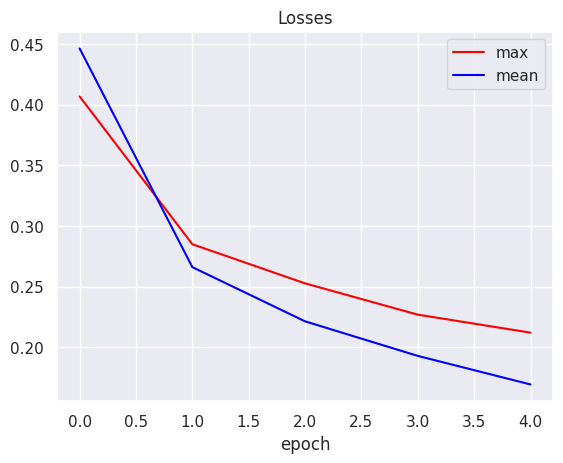

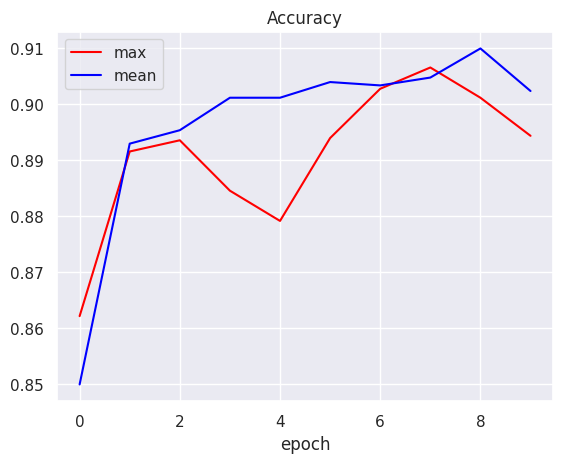

Accuracy для max = 0.8944
Accuracy для mean = 0.9024


In [14]:
plot(losses_type, acc_type)
print(f'Accuracy для max = {last_acc_type['max']:.4f}')
print(f'Accuracy для mean = {last_acc_type['mean']:.4f}')

### Проведение экспериментов по улучшению модели (2 балла за каждый эксперимент)
Чтобы улучшить качество базовой модели, можно попробовать различные идеи экспериментов. Каждый выполненный эксперимент будет оцениваться в 2 балла. Для получения полного балла за этот пункт вам необходимо выполнить по крайней мере 2 эксперимента. Не расстраивайтесь, если какой-то эксперимент не дал вам прироста к качеству: он все равно зачтется, если выполнен корректно.

Вот несколько идей экспериментов:
* **Модель RNN**. Попробуйте другие нейросетевые модели --- LSTM и GRU. Мы советуем обратить внимание на [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), так как интерфейс этого класса ничем не отличается от обычной Vanilla RNN, которую мы использовали на семинаре.
* **Увеличение количества рекуррентных слоев модели**. Это можно сделать с помощью параметра `num_layers` в классе `nn.RNN`. В такой модели выходы первой RNN передаются в качестве входов второй RNN и так далее.
* **Изменение архитектуры после применения RNN**. В базовой модели используется агрегация со всех эмбеддингов. Возможно, вы захотите конкатенировать результат агрегации и эмбеддинг с последнего токена.
* **Подбор гиперпараметров и обучение до сходимости**. Возможно, для получения более высокого качества просто необходимо увеличить количество эпох обучения нейросети, а также попробовать различные гиперпараметры: размер словаря, `dropout_rate`, `hidden_dim`.

Обратите внимание, что главное правило проведения экспериментов --- необходимо совершать одно архитектурное изменение в одном эксперименте. Если вы совершите несколько изменений, то будет неясно, какое именно из изменений дало прирост к качеству.

### Эксперимент 1 - Изменение модели на GRU

In [15]:
class CharLM1(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [16]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}
last_acc_type = {}
models_exp1 = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    model = CharLM1(
        hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    model, losses, acc, last_acc = train(model, optimizer, train_dataloader, eval_dataloader, num_epoch)

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc
    last_acc_type[aggregation_type] = last_acc
    models_exp1[aggregation_type] = model

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

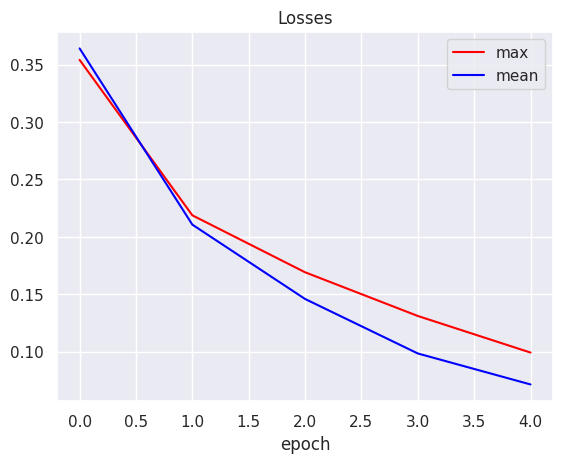

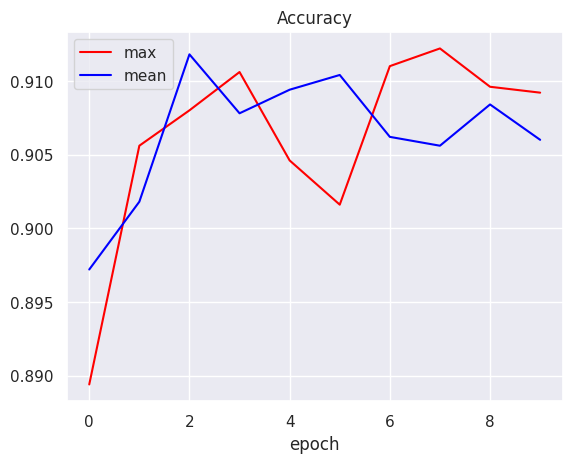

Accuracy для max = 0.9092
Accuracy для mean = 0.9060


In [17]:
plot(losses_type, acc_type)
print(f'Accuracy для max = {last_acc_type['max']:.4f}')
print(f'Accuracy для mean = {last_acc_type['mean']:.4f}')

In [18]:
print(f'Эксперимент 1, точность для max = {evaluate(models_exp1['max'], eval_dataloader):.4f}')
print(f'Эксперимент 1 точность для mean = {evaluate(models_exp1['mean'], eval_dataloader):.4f}')

Эксперимент 1, точность для max = 0.9086
Эксперимент 1 точность для mean = 0.9070


### Вывод 1 - Точность модели увеличилась

### Эксперимент 2 - Уменьшение размера батча, модель GRU не изменилась

In [19]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 16
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

In [20]:
class CharLM2(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [21]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}
last_acc_type = {}
models_exp2 = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    model = CharLM2(
        hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    model, losses, acc, last_acc = train(model, optimizer, train_dataloader, eval_dataloader, num_epoch)

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc
    last_acc_type[aggregation_type] = last_acc
    models_exp2[aggregation_type] = model

Starting training for max


Training epoch 0::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/7500 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/7500 [00:00<?, ?it/s]

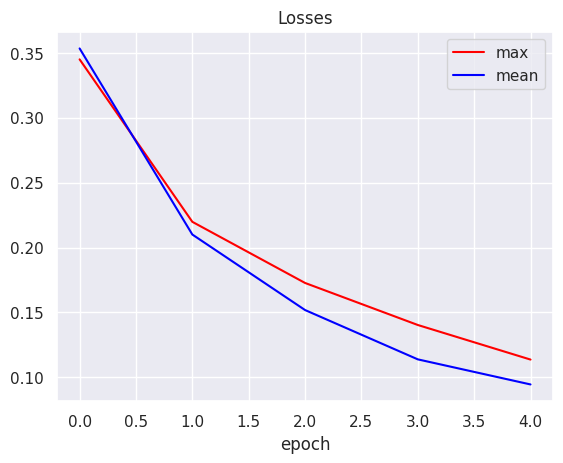

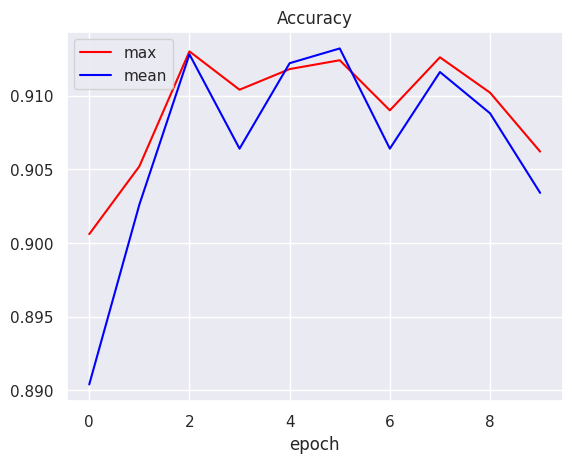

Accuracy для max = 0.9062
Accuracy для mean = 0.9034


In [22]:
plot(losses_type, acc_type)
print(f'Accuracy для max = {last_acc_type['max']:.4f}')
print(f'Accuracy для mean = {last_acc_type['mean']:.4f}')

In [23]:
print(f'Эксперимент 2, точность для max = {evaluate(models_exp2['max'], eval_dataloader):.4f}')
print(f'Эксперимент 2 точность для mean = {evaluate(models_exp2['mean'], eval_dataloader):.4f}')

Эксперимент 2, точность для max = 0.9062
Эксперимент 2 точность для mean = 0.9042


### Вывод 2 - Точность уменьшилась, относительно эксперимента 1

### Эксперимент 3 - Уменьшение порога вхождение в словарь (counter_threshold)

In [24]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 10

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 19562


In [25]:
class CharLM3(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [26]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}
last_acc_type = {}
models_exp3 = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    model = CharLM3(
        hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    model, losses, acc, last_acc = train(model, optimizer, train_dataloader, eval_dataloader, num_epoch)

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc
    last_acc_type[aggregation_type] = last_acc
    models_exp3[aggregation_type] = model

Starting training for max


Training epoch 0::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/7500 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/7500 [00:00<?, ?it/s]

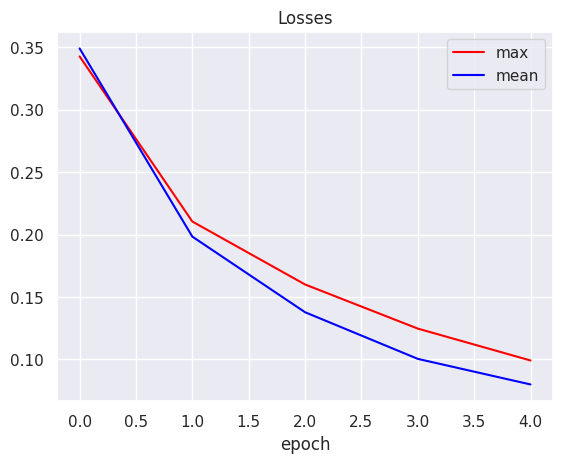

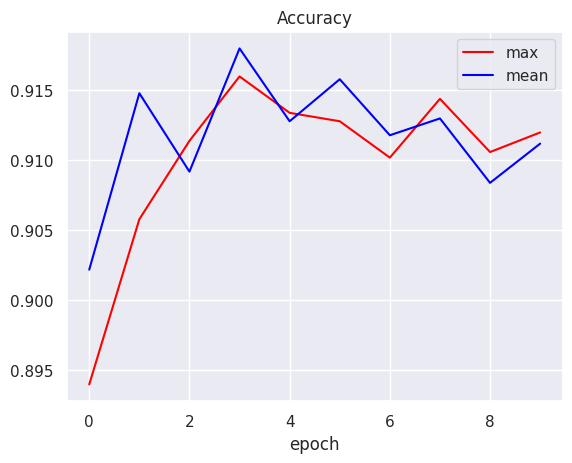

Accuracy для max = 0.9120
Accuracy для mean = 0.9112


In [27]:
plot(losses_type, acc_type)
print(f'Accuracy для max = {last_acc_type['max']:.4f}')
print(f'Accuracy для mean = {last_acc_type['mean']:.4f}')

In [28]:
print(f'Эксперимент 3, точность для max = {evaluate(models_exp3['max'], eval_dataloader):.4f}')
print(f'Эксперимент 3 точность для mean = {evaluate(models_exp3['mean'], eval_dataloader):.4f}')

Эксперимент 3, точность для max = 0.9084
Эксперимент 3 точность для mean = 0.9124


### Вывод 3 - точность увеличилась, относительно экспериментов 1 и 2

### Эксперимент 3.1 - Изменение модели на LSTM

In [49]:
class CharLM3_1(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [50]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}
last_acc_type = {}
models_exp3_1 = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    model = CharLM3_1(
        hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    model, losses, acc, last_acc = train(model, optimizer, train_dataloader, eval_dataloader, num_epoch)

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc
    last_acc_type[aggregation_type] = last_acc
    models_exp3_1[aggregation_type] = model

Starting training for max


Training epoch 0::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/7500 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/7500 [00:00<?, ?it/s]

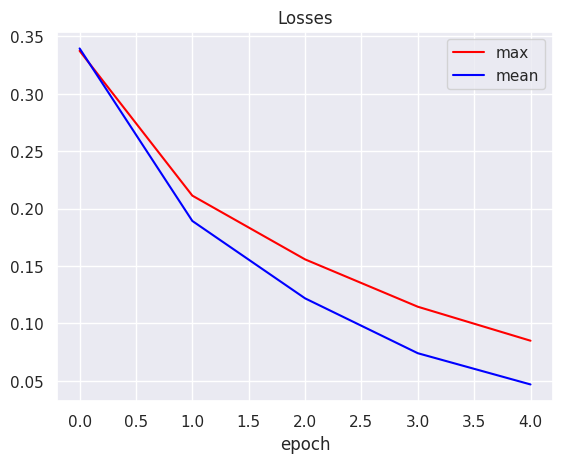

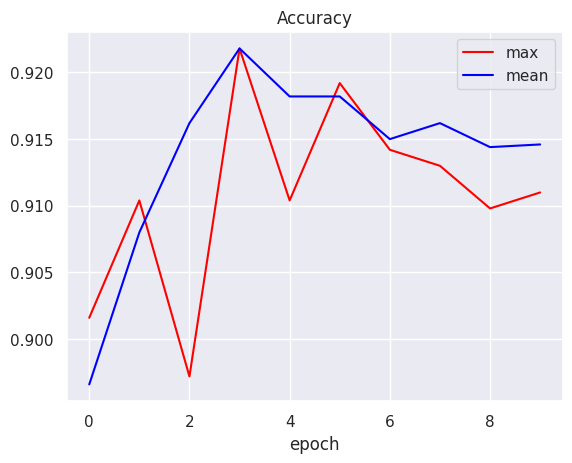

Accuracy для max = 0.9110
Accuracy для mean = 0.9146


In [51]:
plot(losses_type, acc_type)
print(f'Accuracy для max = {last_acc_type['max']:.4f}')
print(f'Accuracy для mean = {last_acc_type['mean']:.4f}')

In [52]:
print(f'Эксперимент 3_1, точность для max = {evaluate(models_exp3_1['max'], eval_dataloader):.4f}')
print(f'Эксперимент 3_1 точность для mean = {evaluate(models_exp3_1['mean'], eval_dataloader):.4f}')

Эксперимент 3_1, точность для max = 0.9124
Эксперимент 3_1 точность для mean = 0.9158


### Вывод 3.1 - Точность модели получилась самой высокой

### Эксперимент 4 - Добавление скрытого слоя

In [29]:
class CharLM4(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=2, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [30]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}
last_acc_type = {}
models_exp4 = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    model = CharLM4(
        hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    model, losses, acc, last_acc = train(model, optimizer, train_dataloader, eval_dataloader, num_epoch)

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc
    last_acc_type[aggregation_type] = last_acc
    models_exp4[aggregation_type] = model

Starting training for max


Training epoch 0::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/7500 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/7500 [00:00<?, ?it/s]

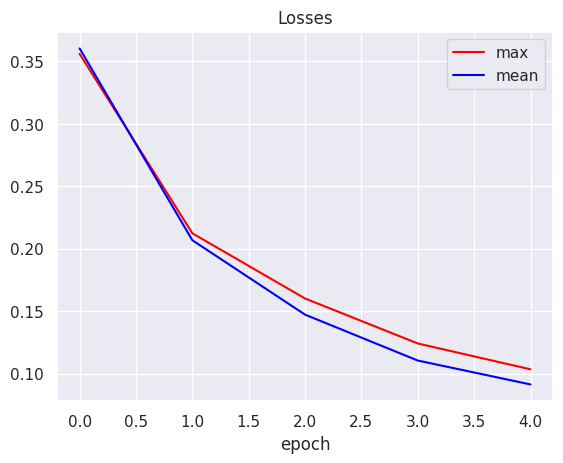

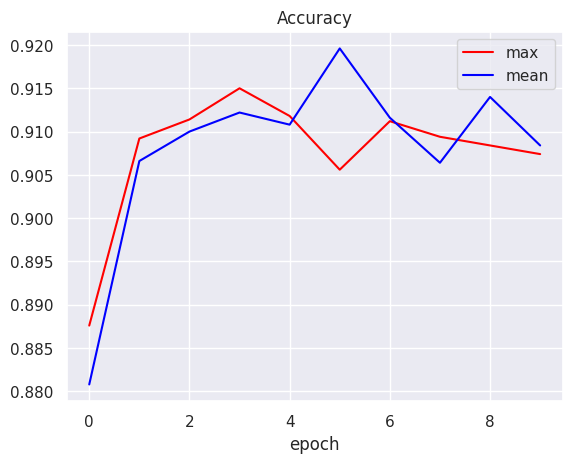

Accuracy для max = 0.9074
Accuracy для mean = 0.9084


In [31]:
plot(losses_type, acc_type)
print(f'Accuracy для max = {last_acc_type['max']:.4f}')
print(f'Accuracy для mean = {last_acc_type['mean']:.4f}')

In [32]:
print(f'Эксперимент 4, точность для max = {evaluate(models_exp4['max'], eval_dataloader):.4f}')
print(f'Эксперимент 4 точность для mean = {evaluate(models_exp4['mean'], eval_dataloader):.4f}')

Эксперимент 4, точность для max = 0.9064
Эксперимент 4 точность для mean = 0.9100


### Вывод 4 - Точность увеличилась, относительно экспериментов 1 и 2, но стала хуже, относительно 3 и 3.1

### Эксперимент 5 - Увеличение размера скрытого слоя

In [33]:
class CharLM5(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=2, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [34]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}
last_acc_type = {}
models_exp5 = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    model = CharLM5(
        hidden_dim=512, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    model, losses, acc, last_acc = train(model, optimizer, train_dataloader, eval_dataloader, num_epoch)

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc
    last_acc_type[aggregation_type] = last_acc
    models_exp5[aggregation_type] = model

Starting training for max


Training epoch 0::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/7500 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/7500 [00:00<?, ?it/s]

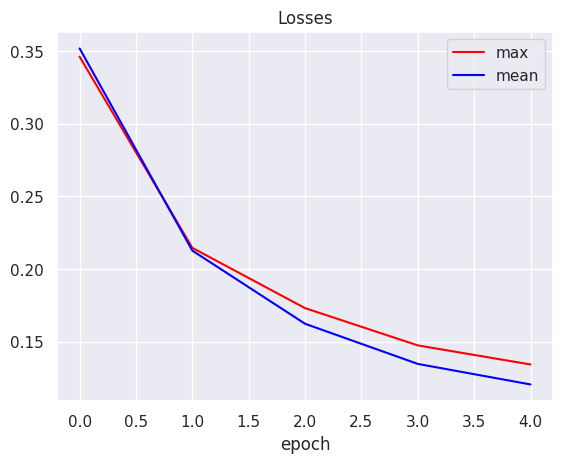

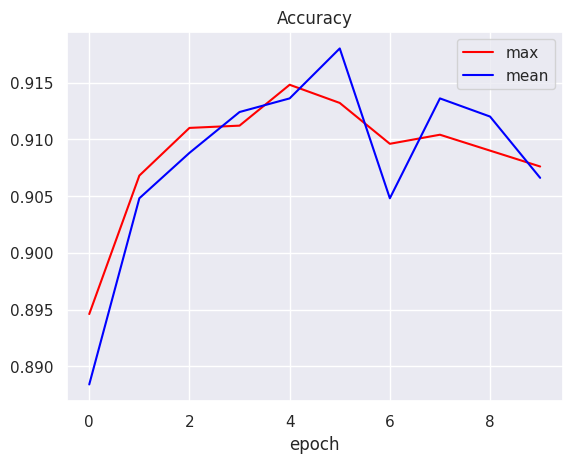

Accuracy для max = 0.9076
Accuracy для mean = 0.9066


In [35]:
plot(losses_type, acc_type)
print(f'Accuracy для max = {last_acc_type['max']:.4f}')
print(f'Accuracy для mean = {last_acc_type['mean']:.4f}')

In [36]:
print(f'Эксперимент 5, точность для max = {evaluate(models_exp5['max'], eval_dataloader):.4f}')
print(f'Эксперимент 5 точность для mean = {evaluate(models_exp5['mean'], eval_dataloader):.4f}')

Эксперимент 5, точность для max = 0.9080
Эксперимент 5 точность для mean = 0.9076


### Вывод 5 - Точность сопоставима с экспериментом 4

### Эксперимент 6 - Увеличение вероятности обнуления значения нейрона (Dropout)

In [37]:
class CharLM6(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=2, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.2)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [38]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}
last_acc_type = {}
models_exp6 = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    model = CharLM6(
        hidden_dim=512, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    model, losses, acc, last_acc = train(model, optimizer, train_dataloader, eval_dataloader, num_epoch)

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc
    last_acc_type[aggregation_type] = last_acc
    models_exp6[aggregation_type] = model

Starting training for max


Training epoch 0::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/7500 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/7500 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/7500 [00:00<?, ?it/s]

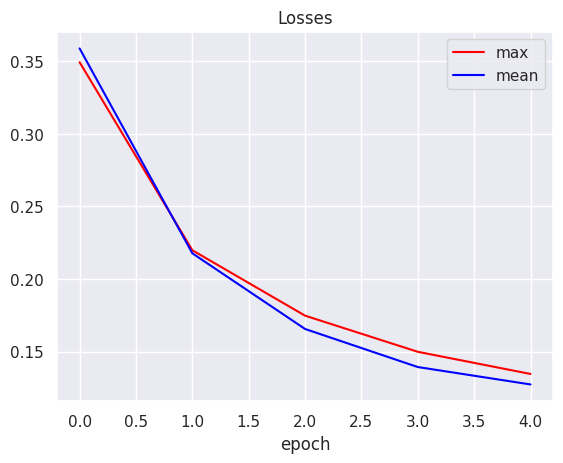

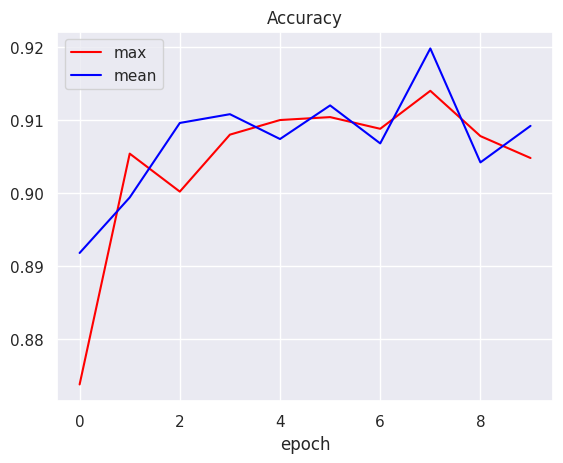

Accuracy для max = 0.9048
Accuracy для mean = 0.9092


In [39]:
plot(losses_type, acc_type)
print(f'Accuracy для max = {last_acc_type['max']:.4f}')
print(f'Accuracy для mean = {last_acc_type['mean']:.4f}')

In [40]:
print(f'Эксперимент 6, точность для max = {evaluate(models_exp6['max'], eval_dataloader):.4f}')
print(f'Эксперимент 6 точность для mean = {evaluate(models_exp6['mean'], eval_dataloader):.4f}')

Эксперимент 6, точность для max = 0.9038
Эксперимент 6 точность для mean = 0.9114


### Вывод 6 - Точность для метода агрегации max уменьшилась, зато для метода mean увеличилась

### Получение высокого качества (3 балла)
В конце вашей работы вы должны указать, какая из моделей дала лучший результат, и вывести качество, которое дает лучшая модель, с помощью функции `evaluate`. Ваша модель будет оцениваться по метрике `accuracy` следующим образом:
* $accuracy < 0.9$ --- 0 баллов;
* $0.9 \leqslant accuracy < 0.91$ --- 1 балл;
* $0.91 \leqslant accuracy < 0.915$ --- 2 балла;
* $0.915 \leqslant accuracy$ --- 3 балла.

#### Наивысшая точность получилась для эксперимента 3.1 с методом агрегации mean

In [57]:
print(f'Эксперимент 3_1, точность для max = {evaluate(models_exp3_1['max'], eval_dataloader):.4f}')
print(f'Эксперимент 3_1, точность для mean = {evaluate(models_exp3_1['mean'], eval_dataloader):.4f}')

Эксперимент 3_1, точность для max = 0.9122
Эксперимент 3_1, точность для mean = 0.9156


### Оформление отчета (2 балла)
В конце работы подробно опишите все проведенные эксперименты.
* Укажите, какие из экспериментов принесли улучшение, а какие --- нет.

 - Улучшение произошло в моделях, где был уменьшен размер батча, уменьшен порог вхождение в словарь (counter_threshold), и применена модель LSTM. Не дали улучшения экспериметы, где была выбрана модель GRU, относительно LSTM, а также эксперименты с увеличением размера скрытого слоя, и количеством слоёв рекуррентной нейронной сети.

* Проанализируйте графики сходимости моделей в проведенных экспериментах. Являются ли колебания качества обученных моделей существенными в зависимости от эпохи обучения, или же сходимость стабильная?
- По графикам можно заметить, что во всех проведённых экспериментах сходимость стабильная (loss), т.е., уменьшается с увеличением числа эпох. Также можно заметить, что у моделей есть колебания в точности, при увеличении числа эпох, но они не являются критичными, так как она < 0.01.

* Укажите, какая модель получилась оптимальной.
- Оптимальной оказалась модель, в которой был применён метод LSTM, а также уменьшен размер батча и уменьшен порог вхождение в словарь (counter_threshold).

Желаем удачи!